# Batch Catalog Extractions

This notebook demonstrates how to query the survey for datacubes based on a list of coordinates. As an example we use a list of SDSS AGN coordinates that overlap HETDEX coverage.

In [1]:
import os.path as op
import numpy as np
from astropy.table import Column, Table, hstack, unique

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from photutils.aperture import CircularAperture
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import time

In [2]:
pdr_dir = '/home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/'
ifu_data = Table.read(op.join( pdr_dir, 'ifu-index.fits'))

In [3]:
# Create SkyCoord Object array for IFU centers
ifu_coords = SkyCoord( ra=ifu_data['ra_cen']*u.deg, dec=ifu_data['dec_cen']*u.deg)

In [4]:
catalog = unique( Table.read('dr16q_hdr5.fits'), keys='sdss_name')

catalog.remove_column('shotid') # this example might be done witih different catalog later
catalog_coords = SkyCoord(ra = catalog['ra'], dec= catalog['dec'], unit='deg')

In [5]:
idx_ifu, idx_catalog, d2d, d3d = catalog_coords.search_around_sky(ifu_coords, 36*u.arcsec)

In [6]:
# create master table that matches IFU observation coverage with catalog objects

In [7]:
table = hstack( [catalog_coords[idx_catalog], catalog[idx_catalog], ifu_data[idx_ifu]] )
table.rename_column('col0', 'coords')

### Use function defined in dexcube/get_spec.py to automate extractions.

In [8]:
from dexcube.get_spec import get_spectra

### Extract Spectra in a Loop. 

We'll extract spectra for some example AGN coordinates.

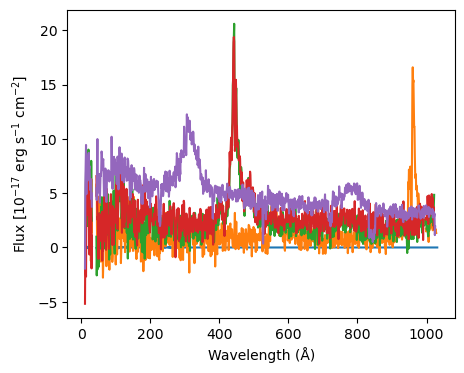

2.1255147457122803


In [9]:
t0 = time.time()
plt.figure(figsize=(5,4))
for row in table[0:9]:
    res = get_spectra( row['coords'], row['shotid'], row['ifuslot'], data_dir=pdr_dir)
    if res is not None:
        plt.plot( res[0], label=row['sdss_name'] )
plt.xlabel("Wavelength (Å)")
plt.ylabel("Flux [10$^{-17}$ erg s$^{-1}$ cm$^{-2}$]")
plt.show()
t1=time.time()
print(t1-t0)

## Run on full catalog using multiprocessing Pool function 

It is recommended to run in parallel if your catalog is very large.

In [10]:
from multiprocessing import Pool
from tqdm import tqdm

In [11]:
# Define a wrapper function for get_spectra to process in Pool
def process_row(row):
    return get_spectra(row['coords'], row['shotid'], row['ifuslot'], data_dir=pdr_dir)


In [12]:
t0 = time.time()
with Pool(processes=20) as pool:
    results = pool.map( process_row, table)
t1 = time.time()
print( 'Bulk spectral extractions done in {:3.2f} min.'.format( (t1-t0)/60))

Bulk spectral extractions done in 5.05 min.


In [13]:
num_rows = len(table)
nan_array = np.full(1036, np.nan, dtype=np.float32)

# Create columns with shape (num_rows, 1036)
spectrum_col = Column(data=np.tile(nan_array, (num_rows, 1)), name='spectrum')
error_col = Column(data=np.tile(nan_array, (num_rows, 1)), name='error')
apcor_col = Column(data=np.tile(nan_array, (num_rows, 1)), name='apcor')

# Add columns to the table
table.add_column(spectrum_col)
table.add_column(error_col)
table.add_column(apcor_col)

In [14]:
for i, row in enumerate(table):
    if results[i] is not None:
        spectrum, error, apcor = results[i]
        table['spectrum'][i] = spectrum
        table['error'][i] = error
        table['apcor'][i] = apcor
    # If result is None, the initialized NaN values remain

In [15]:
# remove coords column as it doesn't jive with astropy table
table.remove_column('coords')

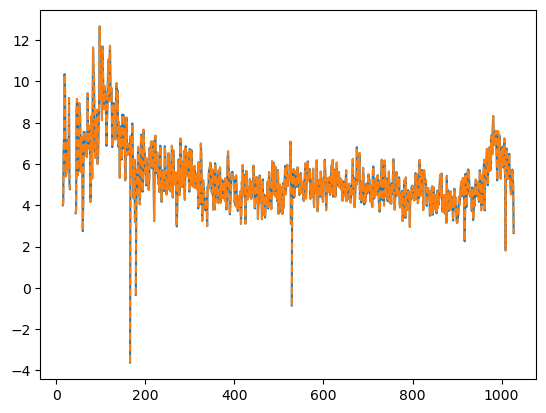

In [16]:
# sanity check
i=105
row = table[i]
res = get_spectra( SkyCoord(ra=row['ra']*u.deg, dec=row['dec']*u.deg), row['shotid'], row['ifuslot'], data_dir=pdr_dir)
plt.plot( res[0], label=row['sdss_name'] )
plt.plot( table['spectrum'][i], linestyle='dashed')

In [17]:
table.write('sdss_agn_spectra_3.5arcsec.fits', overwrite=True)

# Some get_spectra masking examples

As described in the masking notebook (#04), a number of masking types are applied to the survey. 

Default (recommended): keep only perfectly clean voxels.

In [18]:
i=1000

coord = SkyCoord(ra=table['ra'][i], dec=table['dec'][i], unit='deg')
shotid = table['shotid'][i]
ifuslot = table['ifuslot'][i]

In [19]:
spec, err, ap = get_spectra(coord, shotid, ifuslot, data_dir=pdr_dir)

Keep voxels that are flagged with satellites, SAT, but mask all others:

In [20]:
spec, err, ap = get_spectra(
    coord, shotid, ifuslot, pdr_dir,
    include_only_bits="SAT"
)


Exclude all nonzero bits except allow BADCAL:

In [21]:
spec, err, ap = get_spectra(
    coord, shotid, ifuslot, data_dir=pdr_dir,
    exclude_bits="ALL_NONZERO",
    keep_bits="BADCAL"
)
